# Mechanical Failure Risk Model (Baseline + Model Comparison)

Goal: build an initial model that predicts the probability of **mechanical failure** after surgery, using:
- **Pre-op patient measurements** (things we know before surgery)
- **Plan variables** (things the optimizer can change: ALIF/TLIF/XLIF, implants, etc.)

Outputs:
- A baseline model (logistic regression) that returns a **risk probability**
- A comparison against other models (RF, HistGB, XGBoost)
- Saved artifacts so Vanja can plug the model into the optimizer


## 1) Load the dataset

Load the Excel file into a dataframe and clean up column names.
This avoids annoying issues later (extra spaces, line breaks inside column headers).


## 2) Define inputs (features) and output (target)

We explicitly choose which columns the model is allowed to use:

- **Predictors (pre-op):** patient demographics + pre-op alignment / bone quality proxies  
- **Plan variables:** surgical “knobs” that the optimizer may change (ALIF/TLIF/XLIF, rods/screws, etc.)

Then we build:
- `X` = feature table (inputs)
- `y` = target label (`mech_fail_last`)
and drop any rows where `y` is missing.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.config import (
    DATA_PROCESSED,
    MECH_FAIL_FEATURES,
    MECH_FAIL_TARGET
)

import pandas as pd

# Load cleaned data
df = pd.read_csv(DATA_PROCESSED)

# Fix ODI datatype
df["ODI_preop"] = pd.to_numeric(df["ODI_preop"], errors="coerce")

# Check missing columns
missing = set(MECH_FAIL_FEATURES + [MECH_FAIL_TARGET]) - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Create X and y
X = df[MECH_FAIL_FEATURES].copy()
y = df[MECH_FAIL_TARGET].copy()

mask = y.notna()
X = X.loc[mask]
y = y.loc[mask].astype(int)

print("ODI dtype:", X["ODI_preop"].dtype)
print("X shape:", X.shape)
print("Target distribution:\n", y.value_counts())

ODI dtype: float64
X shape: (247, 34)
Target distribution:
 mech_fail_last
0    188
1     59
Name: count, dtype: int64




Check how many patients have mechanical failure vs no failure.
Also check if there are any missing labels (we can’t train on those rows).


In [2]:
target = MECH_FAIL_TARGET

if target not in df.columns:
    raise ValueError(f"{target} not found in dataframe")

print(df[target].value_counts(dropna=False))

mech_fail_last
0.0    188
1.0     59
NaN     24
Name: count, dtype: int64


## 3) Baseline model: logistic regression (with cross-validation)

Start with a simple baseline: logistic regression.
We set up a pipeline that:
- fills missing values
- scales numeric columns (helps logreg)
- one-hot encodes categorical columns

Then we generate **cross-validated probabilities** (each patient is predicted by a model that didn’t train on that patient).
This gives us a more honest view of model behavior than training + testing on the same data.


In [3]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()


preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

model = LogisticRegression(max_iter=2000, class_weight="balanced")
pipe_logreg = Pipeline([("preprocess", preprocess), ("model", model)])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
probs_logreg = cross_val_predict(pipe_logreg, X, y, cv=cv, method="predict_proba")[:, 1]
probs_logreg[:10]

array([0.66829135, 0.37543015, 0.79426561, 0.50532669, 0.54399541,
       0.21775001, 0.30796979, 0.17546465, 0.18196829, 0.40198889])

## 4) Evaluate baseline performance

Two views of “how good is the model?”:

1) **Ranking metrics (no threshold needed)**
- ROC-AUC: how well the model separates failures from non-failures overall
- PR-AUC (Average Precision): focuses more on identifying failures (useful when failures are less common)

2) **Decision metrics (requires a threshold)**
We pick a cutoff (default 0.5 here) to convert probabilities into yes/no predictions and compute:
- precision, recall, F1
- confusion matrix (TP/FP/TN/FN)


In [4]:
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, precision_score, recall_score, f1_score

auc = roc_auc_score(y, probs_logreg)
ap  = average_precision_score(y, probs_logreg)

preds = (probs_logreg >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y, preds).ravel()

print("ROC-AUC:", auc)
print("Avg Precision (PR-AUC):", ap)
print("Precision:", precision_score(y, preds, zero_division=0))
print("Recall:", recall_score(y, preds, zero_division=0))
print("F1:", f1_score(y, preds, zero_division=0))
print({"tn": tn, "fp": fp, "fn": fn, "tp": tp})


ROC-AUC: 0.559682654165164
Avg Precision (PR-AUC): 0.3027221353480132
Precision: 0.2828282828282828
Recall: 0.4745762711864407
F1: 0.35443037974683544
{'tn': np.int64(117), 'fp': np.int64(71), 'fn': np.int64(31), 'tp': np.int64(28)}


## 5) Inspect the highest-risk predictions

Create a results table with:
- predicted failure probability (cross-validated)
- true outcome

Then sort by predicted risk and look at the top patients.
This is an easy way to sanity-check whether high-risk predictions are enriched with actual failures.


In [5]:
results = df.loc[mask, :].copy()
results["pred_fail_prob_cv"] = probs_logreg

results[["pred_fail_prob_cv", "mech_fail_last"]].sort_values("pred_fail_prob_cv", ascending=False).head(15)


,pred_fail_prob_cv,mech_fail_last
222,0.941828,0.0
233,0.940313,1.0
86,0.939944,1.0
39,0.917680,0.0
105,0.909576,0.0
131,0.909271,0.0
173,0.905603,0.0
250,0.904748,1.0
35,0.899420,1.0
136,0.898162,0.0


## 6) Threshold tradeoffs 

The model outputs probabilities, but if we want a yes/no “flag”, we need a threshold.

Lower threshold catches more failures but creates more false alarms.  
Higher threshold means fewer false alarms but misses more failures.

This table helps decide an operating point later (if we ever need a hard cutoff).


In [6]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
rows = []
for t in thresholds:
    preds_t = (probs_logreg >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, preds_t).ravel()
    rows.append({
        "threshold": t,
        "precision": precision_score(y, preds_t, zero_division=0),
        "recall": recall_score(y, preds_t, zero_division=0),
        "f1": f1_score(y, preds_t, zero_division=0),
        "tp": tp, "fp": fp, "tn": tn, "fn": fn
    })

pd.DataFrame(rows)


,threshold,precision,recall,f1,tp,fp,tn,fn
0,0.2,0.239024,0.830508,0.371212,49,156,32,10
1,0.3,0.265060,0.745763,0.391111,44,122,66,15
2,0.4,0.286822,0.627119,0.393617,37,92,96,22
3,0.5,0.282828,0.474576,0.354430,28,71,117,31
4,0.6,0.285714,0.305085,0.295082,18,45,143,41
5,0.7,0.333333,0.254237,0.288462,15,30,158,44


In [7]:
# Fit on all data for demonstration (not evaluation)
pipe_logreg.fit(X, y)

# pick one patient row
i = X.index[0]
x0 = X.loc[[i]].copy()

p_base = pipe_logreg.predict_proba(x0)[:, 1][0]

# toggle ALIF if it exists
x1 = x0.copy()
if "ALIF" in x1.columns:
    x1["ALIF"] = 1 - int(x1["ALIF"].iloc[0])

p_new = pipe_logreg.predict_proba(x1)[:, 1][0]

print("Base risk:", p_base)
print("Toggled ALIF risk:", p_new)
print("Change:", p_new - p_base)


Base risk: 0.6951246675100281
Toggled ALIF risk: 0.8142715653303175
Change: 0.11914689782028942


## 7) Plan sensitivity test 

For optimization, it’s not enough to have a good predictor.
We also need the risk score to **change** when we change plan variables.

Here we do a simple what-if test:
- take the same patient row
- flip one plan knob like TLIF/ALIF/XLIF
- see whether predicted risk changes

If the risk doesn’t move, the optimizer can’t use that knob to rank plans.



In [8]:
# Fit on all data for demonstration
pipe_logreg.fit(X, y)

def toggle_and_diff(col, n=10):
    diffs = []
    idxs = list(X.index)[:n]
    for i in idxs:
        x0 = X.loc[[i]].copy()
        if col not in x0.columns:
            continue
        if pd.isna(x0[col].iloc[0]):
            continue
        try:
            base = pipe_logreg.predict_proba(x0)[:,1][0]
            x1 = x0.copy()
            x1[col] = 1 - int(x1[col].iloc[0])  # assumes 0/1
            new = pipe_logreg.predict_proba(x1)[:,1][0]
            diffs.append(new - base)
        except:
            pass
    return diffs

for c in ["ALIF", "TLIF", "XLIF"]:
    if c in X.columns:
        d = toggle_and_diff(c, n=30)
        print(c, "nonzero diffs:", sum(abs(x) > 1e-6 for x in d), "avg abs change:", np.mean(np.abs(d)) if d else None)


ALIF nonzero diffs: 30 avg abs change: 0.13114699086065912
TLIF nonzero diffs: 30 avg abs change: 0.039553088592149836
XLIF nonzero diffs: 30 avg abs change: 0.14678411346400233


## 8) Turn the model into a callable risk function

This is the interface the optimizer will use:
for each candidate plan, it passes in patient features and plan values and gets back a risk probability.


In [9]:
import numpy as np
import pandas as pd

# Fit model on all data (for scoring / optimizer use)
pipe_logreg.fit(X, y)

FEATURES = list(X.columns)

def score_mech_fail(preop_plan_dict: dict) -> float:
    """
    Input: dict with patient preop + plan fields (keys should match FEATURES).
    Missing keys are allowed (treated as NaN and imputed).
    Output: probability of mechanical failure (0..1).
    """
    row = {c: preop_plan_dict.get(c, np.nan) for c in FEATURES}
    X_new = pd.DataFrame([row], columns=FEATURES)
    return float(pipe_logreg.predict_proba(X_new)[:, 1][0])

#(uses an existing patient row)
demo_dict = X.iloc[0].to_dict()
print("Predicted risk:", score_mech_fail(demo_dict))


Predicted risk: 0.6951246675100281


## 9) Compare models (baseline vs tree/boosting methods)

benchmark multiple models on the same features:
- logistic regression
- random forest
- HistGradientBoosting
- XGBoost

report:
- ROC-AUC and PR-AUC (prediction quality)
- plan sensitivity metrics (does risk move when ALIF/TLIF/XLIF is flipped?)

The goal is to find:
- a strong predictive baseline, and
- a model that is usable inside the optimizer.


In [10]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

# XGBoost (now installed)
from xgboost import XGBClassifier

# -----------------------------
# Preprocessing
# -----------------------------
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()


preprocess_lr = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

preprocess_tree = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
PLAN_VARS = [c for c in ["ALIF", "TLIF", "XLIF"] if c in X.columns]

def plan_sensitivity(pipe, X, plan_vars=PLAN_VARS, n=30):
    out = {}
    idxs = list(X.index)[:min(n, len(X))]
    for col in plan_vars:
        diffs = []
        for i in idxs:
            x0 = X.loc[[i]].copy()
            v = x0[col].iloc[0]
            if pd.isna(v):
                continue
            try:
                vi = int(v)
            except:
                continue
            if vi not in (0, 1):
                continue
            p0 = float(pipe.predict_proba(x0)[:, 1][0])
            x1 = x0.copy()
            x1[col] = 1 - vi
            p1 = float(pipe.predict_proba(x1)[:, 1][0])
            diffs.append(p1 - p0)
        diffs = np.array(diffs) if len(diffs) else np.array([])
        out[col] = float(np.mean(np.abs(diffs))) if len(diffs) else 0.0
    return out

def eval_model(name, preprocess, clf):
    pipe = Pipeline([("prep", preprocess), ("clf", clf)])

    # Honest cross-validated probabilities
    probs = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
    roc = roc_auc_score(y, probs)
    pr  = average_precision_score(y, probs)

    # Fit on all data for plan sensitivity check
    pipe.fit(X, y)
    sens = plan_sensitivity(pipe, X)

    return {
        "model": name,
        "roc_auc": roc,
        "pr_auc": pr,
        **{f"{k}_avg_abs_change": v for k, v in sens.items()}
    }

# -----------------------------
# Models to compare
# -----------------------------
results = []

results.append(eval_model(
    "logreg",
    preprocess_lr,
    LogisticRegression(max_iter=2000, class_weight="balanced")
))

results.append(eval_model(
    "rf",
    preprocess_tree,
    RandomForestClassifier(
        n_estimators=600,
        random_state=42,
        class_weight="balanced_subsample",
        min_samples_leaf=2,
        n_jobs=-1
    )
))

results.append(eval_model(
    "histgb",
    preprocess_tree,
    HistGradientBoostingClassifier(
        random_state=42,
        max_depth=3,
        learning_rate=0.05,
        max_iter=400
    )
))

# XGBoost (conservative config for small n)
results.append(eval_model(
    "xgb",
    preprocess_tree,
    XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=2,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        min_child_weight=5,
        random_state=42,
        eval_metric="logloss"
    )
))

pd.DataFrame(results).sort_values(by=["roc_auc", "pr_auc"], ascending=False)


,model,roc_auc,pr_auc,ALIF_avg_abs_change,TLIF_avg_abs_change,XLIF_avg_abs_change
2,histgb,0.564551,0.294218,0.021603,0.000000,0.000000
0,logreg,0.559683,0.302722,0.131147,0.039553,0.146784
3,xgb,0.534439,0.255112,0.049893,0.000000,0.018738
1,rf,0.527497,0.292502,0.014103,0.005415,0.006981


In [11]:
# Refit final models on full dataset (for saving)
pipe_logreg = Pipeline([
    ("prep", preprocess_lr),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
]).fit(X, y)

pipe_xgb = Pipeline([
    ("prep", preprocess_tree),
    ("clf", XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=2,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        min_child_weight=5, random_state=42, eval_metric="logloss"
    ))
]).fit(X, y)


In [12]:
import joblib, sklearn

from src import config

# Create mech_fail subfolder
mech_fail_dir = config.ARTIFACTS_DIR / "MechanicalFailure"
mech_fail_dir.mkdir(parents=True, exist_ok=True)

FEATURES = list(X.columns)

def save_model(pipe_obj, name):
    bundle = {
        "pipe": pipe_obj,
        "features": FEATURES,
        "target": target,
        "sklearn_version": sklearn.__version__,
        "model_name": name,
    }
    out_path = mech_fail_dir / f"{name}.joblib"
    joblib.dump(bundle, out_path)
    print("Saved:", out_path)

save_model(pipe_logreg, "mech_fail_logreg")
save_model(pipe_xgb, "mech_fail_xgb")

Saved: /Users/vanjaglisic/Documents/UW_MSDS/CAPSTONE/repo work/Data-Science-Capstone/artifacts/MechanicalFailure/mech_fail_logreg.joblib
Saved: /Users/vanjaglisic/Documents/UW_MSDS/CAPSTONE/repo work/Data-Science-Capstone/artifacts/MechanicalFailure/mech_fail_xgb.joblib


# Composite score model (predict post-op composite score from pre-op + plan)


In [13]:
import numpy as np

# Jen's composite score calc 
df["gap_category_postop"] = pd.cut(df["gap_score_postop"], bins=[-np.inf, 2, 6, 13], labels=["P", "MD", "SD"])

def composite_score_calc(df, w1=1, w2=1, w3=1, w4=1, w5=1, w6=1):
    weights = [w1, w2, w3, w4, w5, w6]
    rel_weights = [w / sum(weights) for w in weights]

    gap_score_postop = np.array(df["gap_score_postop"] * 100 / 13)

    l1pa_pen = [0 if abs(i) <= 3 else (abs(i) - 3) ** 2 for i in df["L1PA_ideal_mismatch_postop"]]
    l1pa_pen = np.array(l1pa_pen) / max(l1pa_pen) * 100 if max(l1pa_pen) > 0 else np.zeros(len(df))

    l4s1_pen = [0 if 35 <= i <= 45 else (35 - i) ** 2 if i < 35 else (i - 45) ** 2 for i in df["L4_S1_postop"]]
    l4s1_pen = np.array(l4s1_pen) / max(l4s1_pen) * 100 if max(l4s1_pen) > 0 else np.zeros(len(df))

    t4l1pa_pen = [0 if abs(i) <= 3 else (abs(i) - 3) ** 2 for i in df["T4L1PA_ideal_mismatch_postop"]]
    t4l1pa_pen = np.array(t4l1pa_pen) / max(t4l1pa_pen) * 100 if max(t4l1pa_pen) > 0 else np.zeros(len(df))

    ll_ideal = 0.54 * df["PI_preop"] + 27.6
    ll_mismatch = df["LL_postop"] - ll_ideal
    ll_pen = [0 if abs(i) <= 3 else (abs(i) - 3) ** 2 for i in ll_mismatch]
    ll_pen = np.array(ll_pen) / max(ll_pen) * 100 if max(ll_pen) > 0 else np.zeros(len(df))

    gap_category_improvement = []
    for i in range(len(df)):
        if df["gap_category_postop"].iloc[i] == "P" and df["gap_category"].iloc[i] in ["SD", "MD", "P"]:
            gap_category_improvement.append(0)
        elif df["gap_category_postop"].iloc[i] == "MD" and df["gap_category"].iloc[i] == "SD":
            gap_category_improvement.append(30)
        else:
            gap_category_improvement.append(100)
    gap_category_improvement = np.array(gap_category_improvement)

    composite = (
        rel_weights[0] * gap_score_postop +
        rel_weights[1] * l1pa_pen +
        rel_weights[2] * l4s1_pen +
        rel_weights[3] * t4l1pa_pen +
        rel_weights[4] * ll_pen +
        rel_weights[5] * gap_category_improvement
    )
    return composite

df["composite_score"] = composite_score_calc(df)
df["composite_score"].describe()


count    268.000000
mean      19.030357
std       13.000397
min        0.000000
25%        9.544963
50%       16.361256
75%       29.256139
max       57.003920
Name: composite_score, dtype: float64

In [14]:
from src import config

PATIENT_FIXED_COLS = config.PATIENT_FIXED_COLS
PLAN_COLS = config.PLAN_COLS

# Exclude GAP-related predictors for composite regression
PREDICTORS = [p for p in PATIENT_FIXED_COLS if "gap" not in p]

FEATURES_COMP = PREDICTORS + PLAN_COLS

y_comp = df["composite_score"].copy()
mask_comp = y_comp.notna()

X_comp = df.loc[mask_comp, FEATURES_COMP].copy()
y_comp = y_comp.loc[mask_comp].astype(float)

X_comp.shape, y_comp.describe()


((268, 32),
 count    268.000000
 mean      19.030357
 std       13.000397
 min        0.000000
 25%        9.544963
 50%       16.361256
 75%       29.256139
 max       57.003920
 Name: composite_score, dtype: float64)

In [15]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
cat_cols_comp = X_comp.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols_comp = X_comp.select_dtypes(exclude=["object", "string", "category"]).columns.tolist()


preprocess_tree_comp = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols_comp),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols_comp),
])


pipe_comp = Pipeline([
    ("prep", preprocess_tree_comp),
    ("reg", HistGradientBoostingRegressor(
        random_state=42,
        max_depth=3,
        learning_rate=0.05,
        max_iter=400
    ))
])

pred_comp = cross_val_predict(pipe_comp, X_comp, y_comp, cv=cv_reg)

mae  = mean_absolute_error(y_comp, pred_comp)
mse  = mean_squared_error(y_comp, pred_comp)
rmse = np.sqrt(mse)
r2   = r2_score(y_comp, pred_comp)

print("Composite score CV MAE:", mae)
print("Composite score CV RMSE:", rmse)
print("Composite score CV R2:", r2)


Composite score CV MAE: 11.602263115910285
Composite score CV RMSE: 14.144538301341797
Composite score CV R2: -0.1881953548508899


In [16]:
pipe_comp.fit(X_comp, y_comp)
FEATURES_COMP = list(X_comp.columns)

def score_composite(preop_plan_dict: dict) -> float:
    row = {c: preop_plan_dict.get(c, np.nan) for c in FEATURES_COMP}
    X_new = pd.DataFrame([row], columns=FEATURES_COMP)
    return float(pipe_comp.predict(X_new)[0])

demo_dict = X_comp.iloc[0].to_dict()
print("Predicted composite score:", score_composite(demo_dict))


Predicted composite score: 11.792707442427487


In [17]:
FEATURES_COMP

['age',
 'sex',
 'bmi',
 'C7CSVL_preop',
 'SVA_preop',
 'T4PA_preop',
 'L1PA_preop',
 'LL_preop',
 'L4S1_preop',
 'PT_preop',
 'PI_preop',
 'SS_preop',
 'cobb_main_curve_preop',
 'FC_preop',
 'tscore_femneck_preop',
 'HU_UIV_preop',
 'HU_UIVplus1_preop',
 'HU_UIVplus2_preop',
 'global_tilt_preop',
 'CCI',
 'ASA_CLASS',
 'revision',
 'ODI_preop',
 'UIV_implant',
 'num_levels_cat',
 'num_interbody_fusion_levels',
 'ALIF',
 'XLIF',
 'TLIF',
 'num_rods',
 'num_pelvic_screws',
 'osteotomy']

## Mechanical Failure Prediction Model Evaluation
Although multiple models were compared (Logistic Regression, Random Forest, HistGradientBoosting, XGBoost), the **Logistic Regression model is used for optimization**, as it demonstrates meaningful responsiveness to surgical plan variables while maintaining comparable predictive performance.

The following plots illustrate:

- ROC curve (model discrimination ability)
- Predicted probability distribution
- Feature importance and interpretability analysis

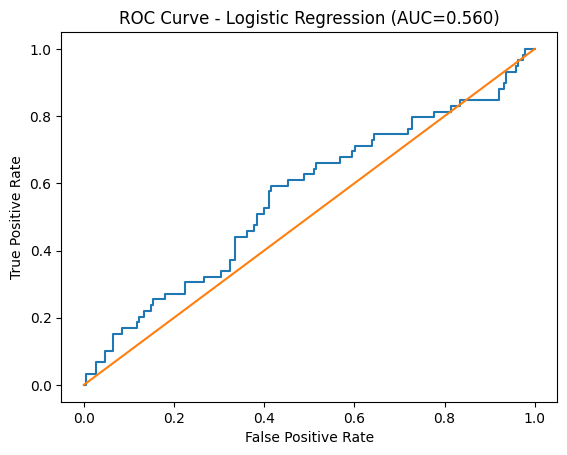

0.559682654165164

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

pipe_logreg = Pipeline([
    ("prep", preprocess_lr),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

probs_logreg = cross_val_predict(
    pipe_logreg, X, y,
    cv=cv,
    method="predict_proba"
)[:, 1]

fpr, tpr, _ = roc_curve(y, probs_logreg)
roc_auc = roc_auc_score(y, probs_logreg)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title(f"ROC Curve - Logistic Regression (AUC={roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

roc_auc

In [19]:
# Fit logreg on full dataset (not CV)
pipe_logreg.fit(X, y)

# Get transformed feature names
feature_names = pipe_logreg.named_steps["prep"].get_feature_names_out()

# Get coefficients
coefs = pipe_logreg.named_steps["clf"].coef_[0]

import pandas as pd

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_coefficient": abs(coefs)
}).sort_values("abs_coefficient", ascending=False)

# Clean feature names
coef_df["feature"] = (
    coef_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

coef_df.head(15)

,feature,coefficient,abs_coefficient
14,HU_UIV_preop,-0.820063,0.820063
34,gap_category_SD,0.779763,0.779763
6,LL_preop,0.740443,0.740443
9,PI_preop,-0.636071,0.636071
27,osteotomy,-0.627910,0.627910
41,UIV_implant_Hook,-0.584031,0.584031
40,UIV_implant_FS,0.544216,0.544216
44,num_levels_cat_lower,-0.377120,0.377120
13,tscore_femneck_preop,0.376484,0.376484
43,num_levels_cat_higher,0.372476,0.372476


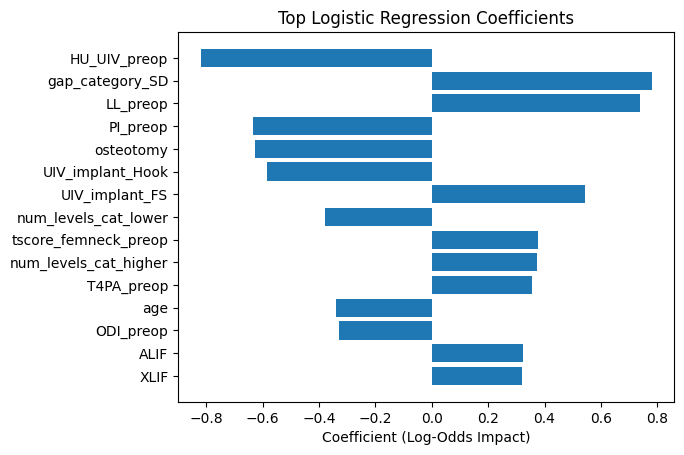

In [20]:
import matplotlib.pyplot as plt

top = coef_df.head(15).iloc[::-1]

plt.figure()
plt.barh(top["feature"], top["coefficient"])
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient (Log-Odds Impact)")
plt.show()

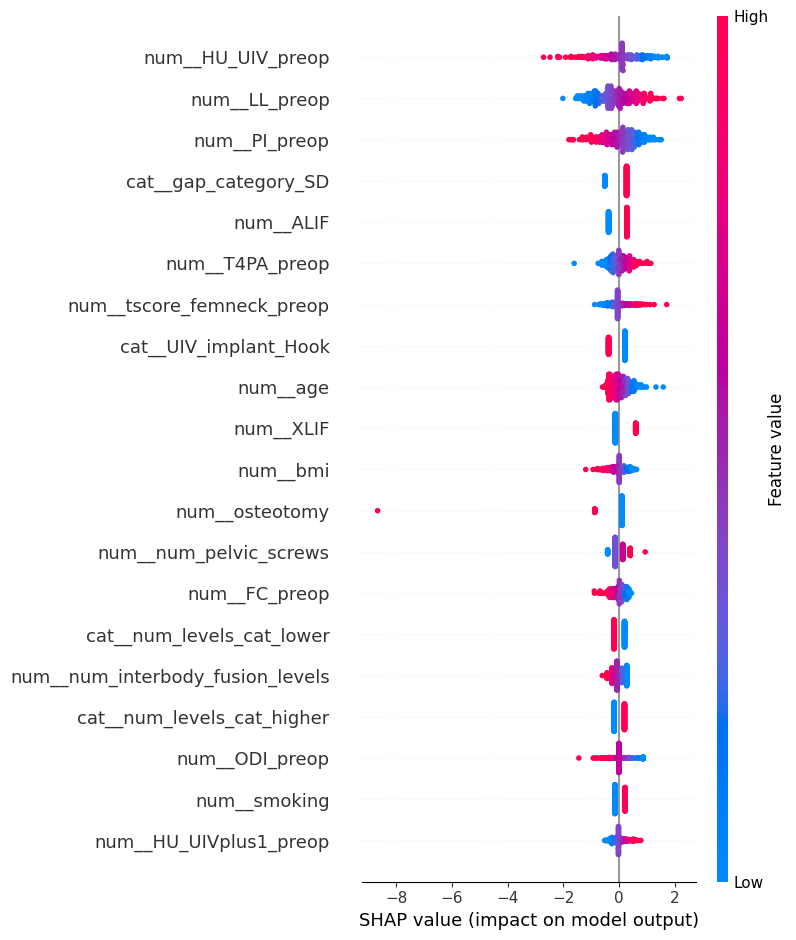

In [21]:
import shap

# Fit pipeline fully
pipe_logreg.fit(X, y)

# Extract preprocessed matrix
X_processed = pipe_logreg.named_steps["prep"].transform(X)

explainer = shap.LinearExplainer(
    pipe_logreg.named_steps["clf"],
    X_processed
)

shap_values = explainer.shap_values(X_processed)

shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=feature_names,
    show=False
)

plt.show()

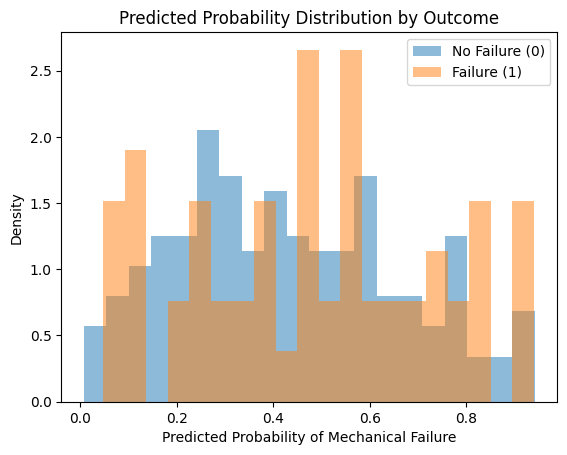

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

df_plot = pd.DataFrame({
    "prob": probs_logreg,
    "actual": y.values
})

plt.figure()
for label in [0, 1]:
    subset = df_plot[df_plot["actual"] == label]
    plt.hist(subset["prob"], bins=20, alpha=0.5, density=True)

plt.title("Predicted Probability Distribution by Outcome")
plt.xlabel("Predicted Probability of Mechanical Failure")
plt.ylabel("Density")
plt.legend(["No Failure (0)", "Failure (1)"])
plt.show()